# Homework 3: Compare Linear Models for Regrssion

In this lab assignment, you will work with an extdened Daibetes datset.

The original diabetes dataset has 442 instance, 10 features and 1 target variable. Based on the 10 original features, .

##Here is the process:
* Part 1 Import the libraries. (Codes provided)
* Part 2 Import the original diabetes dataset. Explore the original dataset. (Codes provided)
* Part 3 Build an exteded diabetes dataset by adding polynomial and interaction Features. (Codes provided)
* Part 4 Split the extended dataset (test_size=0.20, random_state=8). Check the shape of training and test sets. (Codes provided)
* Part 5 Train and evaluate with linear regression model. Discuss your findings. (Your Turn)
* Part 6 Part 7 Train and evalute with ridge regression. (Your turn)
* Part 7 Train and evalute with lasso regression. (Your Turn)
* Part 8 Summary. (Your turn)

# Part 1 Import the libaries.

In [1]:
# Import the libaries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

# Part 2 Import the original diabetes dataset. Explore the dataset.

In [2]:
# Import the original diabetes dataset
from sklearn.datasets import load_diabetes

# Explore the original diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n", diabetes.keys())
print(diabetes.DESCR)

X shape: (442, 10)
y shape: (442,)

 dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol /

First 5 rows of the original Diabetes dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Summary statistics of the original Diabetes dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


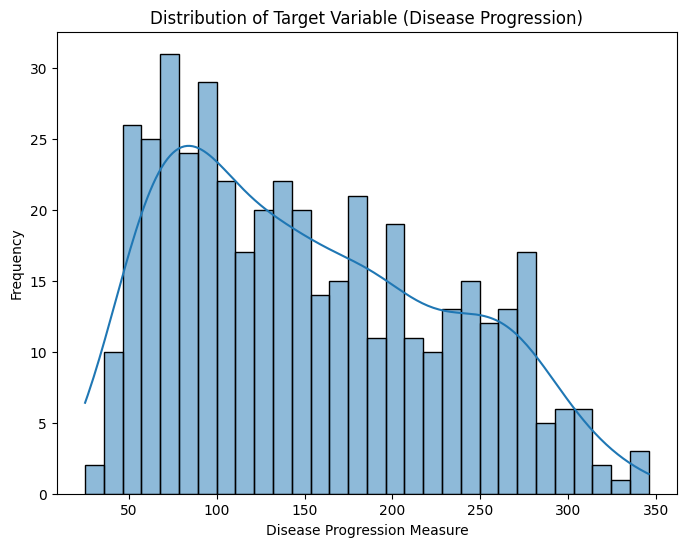

In [3]:
# Create a Pandas DataFrame from diabetes.data and feature_names
df_diabetes_original = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the diabetes.target array as a new column named 'target'
df_diabetes_original['target'] = diabetes.target

# Display the first 5 rows of df_diabetes_original
print("First 5 rows of the original Diabetes dataset:")
display(df_diabetes_original.head())

# Display the summary statistics of df_diabetes_original
print("\nSummary statistics of the original Diabetes dataset:")
display(df_diabetes_original.describe())

# Create a histogram of the 'target' column
plt.figure(figsize=(8, 6))
sns.histplot(df_diabetes_original['target'], bins=30, kde=True)
plt.title('Distribution of Target Variable (Disease Progression)')
plt.xlabel('Disease Progression Measure')
plt.ylabel('Frequency')
plt.show()

# Part 3 Generate polynomial and interaction features - dimensionality increase

Total new features = 10 (original) + 10 (squared) + 45 (interactions) = **65 features**.

This transformation aims to allow linear models to capture more complex, non-linear relationships within the data by explicitly creating these higher-order and interaction terms.

In [4]:
from sklearn.preprocessing import PolynomialFeatures

# Instantiate PolynomialFeatures with degree=2
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the original feature matrix
X_poly = poly.fit_transform(diabetes.data)

# Get feature names for the polynomial features
poly_feature_names = poly.get_feature_names_out(diabetes.feature_names)

# Create a Pandas DataFrame from X_poly
df_diabetes_extended = pd.DataFrame(X_poly, columns=poly_feature_names)

# Add the original diabetes.target array as a new column named 'target'
df_diabetes_extended['target'] = diabetes.target

print("Shape of X_poly:", X_poly.shape)
print("\nFirst 5 rows of the extended Diabetes dataset:")
display(df_diabetes_extended.head())

Shape of X_poly: (442, 65)

First 5 rows of the extended Diabetes dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,...,s3 s4,s3 s5,s3 s6,s4^2,s4 s5,s4 s6,s5^2,s5 s6,s6^2,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,...,0.000113,-0.000864,0.000766,0.000007,-0.000052,0.000046,0.000396,-0.000351,0.000311,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,...,-0.002939,-0.005085,-0.006861,0.001560,0.002699,0.003641,0.004669,0.006300,0.008502,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,...,0.000084,-0.000093,0.000839,0.000007,-0.000007,0.000067,0.000008,-0.000074,0.000672,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,...,-0.001236,-0.000818,0.000337,0.001177,0.000778,-0.000321,0.000515,-0.000212,0.000088,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,...,-0.000021,-0.000260,-0.000380,0.000007,0.000083,0.000121,0.001023,0.001492,0.002175,135.0


# Part 4 Split the extended dataset


In [5]:
from sklearn.model_selection import train_test_split

# Extract features (X_extended) and target (y_extended) from the extended DataFrame
X_extended = df_diabetes_extended.drop('target', axis=1)
y_extended = df_diabetes_extended['target']

# Split the extended dataset into training and testing sets
X_train_extended, X_test_extended, y_train_extended, y_test_extended = train_test_split(
    X_extended, y_extended, test_size=0.20, random_state=8)

# Check the training set and testing set
print("Shapes of the extended datasets after splitting:")
print(f"X_train_extended shape: {X_train_extended.shape}")
print(f"y_train_extended shape: {y_train_extended.shape}")
print(f"X_test_extended shape: {X_test_extended.shape}")
print(f"y_test_extended shape: {y_test_extended.shape}")

Shapes of the extended datasets after splitting:
X_train_extended shape: (353, 65)
y_train_extended shape: (353,)
X_test_extended shape: (89, 65)
y_test_extended shape: (89,)


# Part 5 Train and evaluate linear regression

In [6]:
# Part 5 Your Codes


In [7]:
#Fitting the linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X_train_extended, y_train_extended)


In [8]:
# Check the training and testing scores

print("Training set score: {:.2f}".format(lr.score(X_train_extended, y_train_extended)))
print("Testing set score: {:.2f}".format(lr.score(X_test_extended, y_test_extended)))

Training set score: 0.61
Testing set score: 0.42


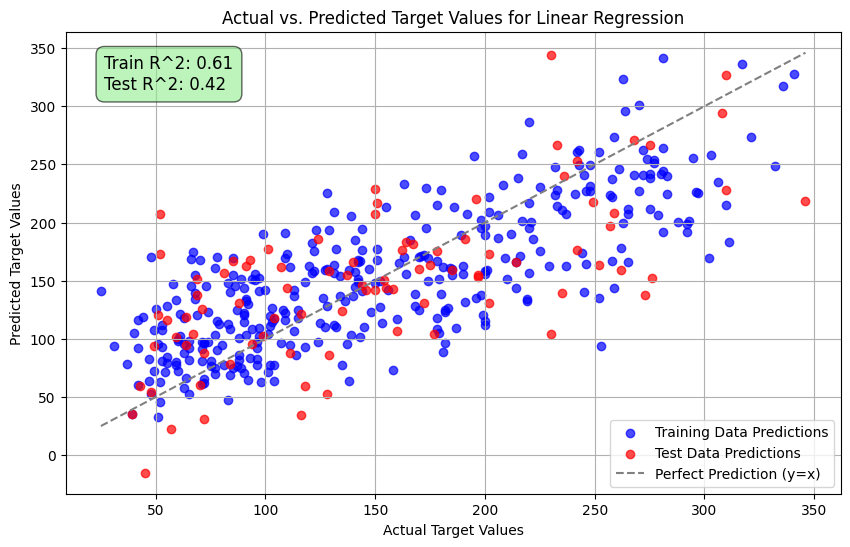

In [9]:
# Visualize

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot training data predictions
plt.scatter(y_train_extended, lr.predict(X_train_extended), label='Training Data Predictions', alpha=0.7, color='blue')

# Plot test data predictions
plt.scatter(y_test_extended, lr.predict(X_test_extended), label='Test Data Predictions', alpha=0.7, color='red')

# Plot a perfect prediction line (y=x)
plt.plot([min(y_test_extended.min(), y_train_extended.min()), max(y_test_extended.max(), y_train_extended.max())],
         [min(y_test_extended.min(), y_train_extended.min()), max(y_test_extended.max(), y_train_extended.max())],
         linestyle='--', color='gray', label='Perfect Prediction (y=x)')

plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Actual vs. Predicted Target Values for Linear Regression')
plt.legend()
plt.grid(True)

# Get current axes to place text
ax = plt.gca()

# Display training and test scores on the plot
train_score = lr.score(X_train_extended, y_train_extended)
test_score = lr.score(X_test_extended, y_test_extended)
plt.text(0.05, 0.95, f'Train R^2: {train_score:.2f}\nTest R^2: {test_score:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='lightgreen', alpha=0.6))

plt.show()

### Part 5 Discussion: Summarize your findings from linear regression

For starters, this dataset has high noise since factors related to diabetes progression can be unpredictable at times. It has a training score of 0.61 and a testing score of 0.42, suggesting some overfitting. However, because the data is sensitive to noise, a training score of 0.61 is reasonable. In addition, many of the data points are scattered around the predicted line in both the training and testing sets, which further suggests that the model might not be capturing the relationship perfectly. Overall, this shows that the model captures some of the relationship, but because the dataset contains a lot of variability, it cannot predict unseen data perfectly.

# Part 6 Train and evluate ridge regression

Perform Ridge regression with three specific alpha values (0.01, 0.1, 1.0). For each alpha, instantiate and fit a Ridge model, then evaluate and print its R-squared scores on both the training and test sets.


In [10]:
# Part 6 Your Codes
# Import Ridge. The defaul value is alpha=1.0.

from sklearn.linear_model import Ridge

#Alpha value of 1.0
ridge = Ridge(alpha=1).fit(X_train_extended, y_train_extended)
print("Training set score: {:.2f}".format(ridge.score(X_train_extended, y_train_extended)))
print("Test set score: {:.2f}".format(ridge.score(X_test_extended, y_test_extended)))

Training set score: 0.43
Test set score: 0.46


In [11]:
#Alpha value of 0.1
ridge01 = Ridge(alpha=0.1).fit(X_train_extended, y_train_extended)
print("Training set score: {:.2f}".format(ridge01.score(X_train_extended, y_train_extended)))
print("Test set score: {:.2f}".format(ridge01.score(X_test_extended, y_test_extended)))

Training set score: 0.51
Test set score: 0.51


In [12]:
#Alpha value of 0.01
ridge001 = Ridge(alpha=0.01).fit(X_train_extended, y_train_extended)
print("Training set score: {:.2f}".format(ridge001.score(X_train_extended, y_train_extended)))
print("Test set score: {:.2f}".format(ridge001.score(X_test_extended, y_test_extended)))

Training set score: 0.54
Test set score: 0.53


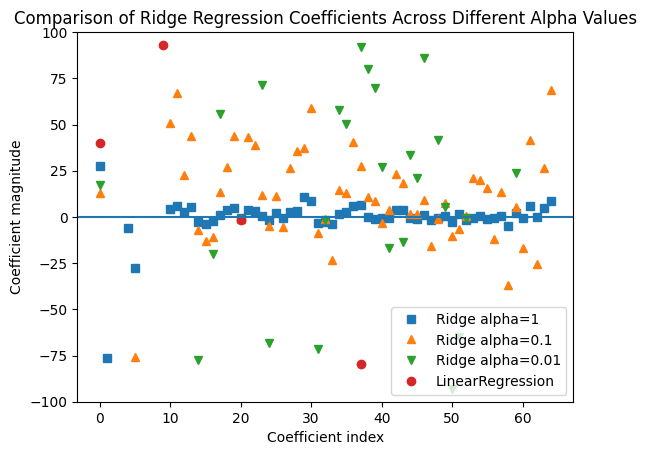

In [13]:
#Plotting the graph
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge01.coef_, '^', label="Ridge alpha=0.1")
plt.plot(ridge001.coef_, 'v', label="Ridge alpha=0.01")

plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.title("Comparison of Ridge Regression Coefficients Across Different Alpha Values")
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylim(-100, 100)
plt.legend()

### Part 6 Discussion:
* Summarize your findings from ridge regression
* Which ridge regression model is better? Why?

Model 1 (Alpha = 1.0): This model has a training score of 0.43 and a testing score of 0.46. These scores are relatively low, suggesting slight underfitting. In addition, many of the datapoints for both the training and testing sets stick close to the predicted line, indicating that the model is overly simplified and not fully capturing the relationship.

Model 2 (Alpha = 0.1): This model has a training score of 0.51 and a testing score of 0.51. Since the scores are the same and slightly higher than Model 1, it suggests a better balance between bias and variance. There are no clear signs of overfitting or underfitting.

Model 3 (Alpha = 0.01): This model has a training score of 0.54 and a testing score of 0.53. These scores are still slightly higher and very close together, indicating good generalization with very slight overfitting. The datapoints are scattered around the predicted line, showing that the model captures more of the relationship compared to the models with a higher alpha value.

The ridge regression model performs best on Model 3 since it has the highest training and testing scores while maintaining a very small gap between them, meaning it generalizes well without singificantly overfitting. In addition, as the alpha value decreases, the model becomes less restricted, allowing it to capture more of the relationship without creating a large gap between the training and testing scores.


# Part 7 Train and evalute lasso regression

Perform Lasso regression with three specific alpha values (0.01, 0.1, 1.0). For each alpha, instantiate and fit a Lasso model, then evaluate and print its R-squared scores on both the training and test sets, including the number of non-zero coefficients.


In [14]:
# Part 7 Your Codes

#Importing Lasso regression
from sklearn.linear_model import Lasso

#Alpha value of 1.0
lasso = Lasso(alpha=1.0).fit(X_train_extended, y_train_extended)
print("Training set score: {:.2f}".format(lasso.score(X_train_extended, y_train_extended)))
print("Test set score: {:.2f}".format(lasso.score(X_test_extended, y_test_extended)))
print("Number of features used:", np.sum(lasso.coef_ != 0))

Training set score: 0.34
Test set score: 0.40
Number of features used: 3


In [15]:
#Alpha value of 0.1
lasso01 = Lasso(alpha=0.1, max_iter=100000).fit(X_train_extended, y_train_extended)
print("Training set score: {:.2f}".format(lasso01.score(X_train_extended, y_train_extended)))
print("Test set score: {:.2f}".format(lasso01.score(X_test_extended, y_test_extended)))
print("Number of features used:", np.sum(lasso01.coef_ != 0))

Training set score: 0.51
Test set score: 0.52
Number of features used: 7


In [16]:
#Alpha value of 0.01
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train_extended, y_train_extended)
print("Training set score: {:.2f}".format(lasso001.score(X_train_extended, y_train_extended)))
print("Test set score: {:.2f}".format(lasso001.score(X_test_extended, y_test_extended)))
print("Number of features used:", np.sum(lasso001.coef_ != 0))

Training set score: 0.54
Test set score: 0.53
Number of features used: 14


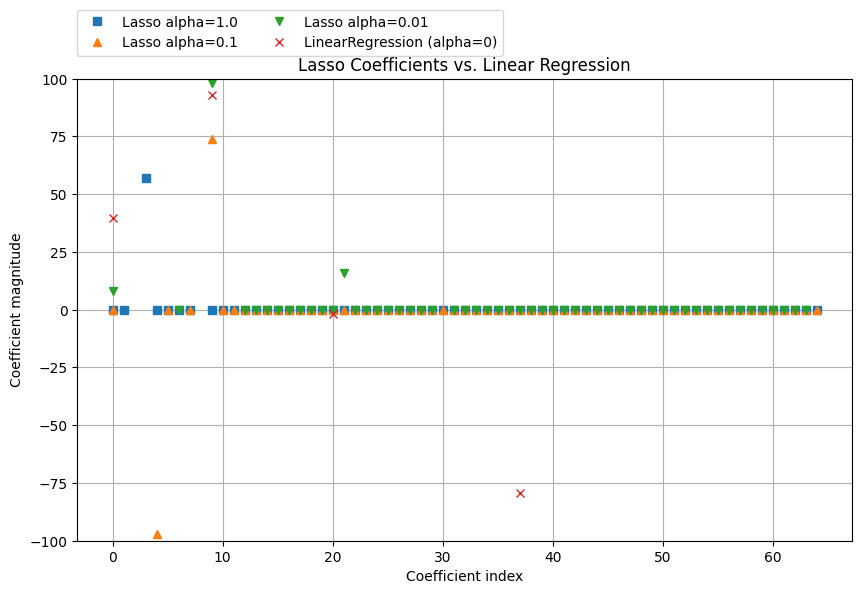

In [17]:
# Visualization

plt.figure(figsize=(10, 6))
plt.plot(lasso.coef_, 's', label="Lasso alpha=1.0")
plt.plot(lasso01.coef_, '^', label="Lasso alpha=0.1")
plt.plot(lasso001.coef_, 'v', label="Lasso alpha=0.01")
plt.plot(lr.coef_, 'x', label="LinearRegression (alpha=0)")

plt.legend(ncol=2, loc=(0, 1.05))
plt.ylim(-100, 100) # Keep consistent y-limits for comparison
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.title("Lasso Coefficients vs. Linear Regression")
plt.grid(True)

### Part 7 Your Discussion:
* Summarize your findings from lasso regression
* Which lasso regression model is better? Why?

Model 1 (Alpha = 1.0): This model has a training score of 0.34 and a testing score of 0.40. These scores are relatively low, suggesting slight underfitting. In addition, many of the datapoints for both the training and testing sets stick close to the predicted line, indicating that the model is overly simplified and not fully capturing the relationship. This model has 3 features.

Model 2 (Alpha = 0.1): This model has a training score of 0.51 and a testing score of 0.52. Since the scores are very similar and slightly higher than Model 1, it suggests a better balance between bias and variance. The model is slightly underfitting. This model has 7 features.

Model 3 (Alpha = 0.01): This model has a training score of 0.54 and a testing score of 0.53. These scores are still slightly higher and very close together, indicating good generalization with very slight overfitting. The datapoints are scattered around the predicted line, showing that the model captures more of the relationship compared to the models with a higher alpha value. This model has 14 features.

The lasso regression model performs best on Model 2 since it has a high training and testing score with a small gap while maintaing less features compared to model 3.

Additional analysis: As the alpha value goes down, more features are implemented into the model.

# Part 8 Summary

### Part 8 Your Discusssion: Overall, which model is better? Why?

I would say that Model 2 of the lasso regression performs the best because:

1: It has a reasonably high training and testing score

2: There is a minimal gap between them

3: It has less dimensions than the other models that perform similar.